In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
import pyvinecopulib as pv

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats


/home/pgrad2/2448355h/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using device: cuda


#### Define a GPDFlow

In [2]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/01_Output/GPDFlow/"

dim = 25


#### Find a suitable threshold for the simulated data

In [3]:
# ── Define B_1 (5×3) and build full 25×3 loading matrix ─────────────────────
B_1 = np.array([
    [ 0.4,  1.0,           0],
    [ 0.4,  -1,            0],
    [ 0.4,  np.sqrt(3)/2,  0.5],
    [ 0.4, -np.sqrt(3)/2,  0.5],
    [ 0.4, -0,             1],
])
B_full = np.vstack([B_1] * 10)   # shape (25, 3) — B_1 stacked 5 times vertically

# ── Full 25-dim parameters (slice [:dim] at every usage) ─────────────────────
K   = 3    # number of mixture components
K_f = 3    # latent factors per component (= columns of B_full)

# Component means: 3 shifts of the base pattern [1, 1.5, 2, 2.5, 3] × 5 blocks
_mu_base    = np.array([1.0, -1.5, 2.0, -2.5, 3.0] * 10)   # shape (25,)
mus_full    = [_mu_base, np.zeros(50), -_mu_base]         # components 0, 1, 2

# Diagonal noise std — uniform 0.5 across all dims and components
psis_full   = [np.full(50, 0.5) for _ in range(K)]

# Marginal parameters — defined once at 25-dim, sliced to :dim below
sigma_full  = np.array([0.5, 1.2, 1.0, 1.5, 0.8] * 10)   # shape (25,)
gamma_full  = np.array([-0.1, 0.2, 0.0, 0.1, 0.3] * 10)  # shape (25,)

# Equal mixing weights
pi = np.ones(K) / K

# ── Slice everything to the active dimension ──────────────────────────────────
B    = B_full[:dim, :]               # (dim, 3)
mus  = [m[:dim]  for m in mus_full]  # list of K dim-vectors
psis = [p[:dim]  for p in psis_full] # list of K dim-vectors

# ── Generate T from the MoG ───────────────────────────────────────────────────
np.random.seed(42)
n_samples   = 1000
comp_labels = np.random.choice(K, size=n_samples, p=pi)
T_samples   = np.zeros((n_samples, dim))
for i, m in enumerate(comp_labels):
    F_i   = np.random.randn(K_f)            # F ~ N(0, I_3)
    eps_i = np.random.randn(dim) * psis[m]  # eps ~ N(0, D_m)
    T_samples[i] = mus[m] + B @ F_i + eps_i

# ── Visualise T (2-D only) ───────────────────────────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    sc = ax.scatter(T_samples[:, 0], T_samples[:, 1],
                    c=comp_labels, cmap='tab10', alpha=0.3, s=3)
    plt.colorbar(sc, ax=ax, label='Component')
    ax.set_xlabel('$T_1$');  ax.set_ylabel('$T_2$')
    ax.set_title('Mixture-of-Gaussians generator $T$ (2D)')
    plt.tight_layout();  plt.show()

# ── Standardised mGPD:  Z = E + T − max(T) ──────────────────────────────────
T_t   = torch.tensor(T_samples, dtype=torch.float32)
T_max = torch.max(T_t, dim=1, keepdim=True).values
T_cen = T_t - T_max

E = torch.empty(n_samples).exponential_(1.0).unsqueeze(1)
Z = E + T_cen   # standardised mGPD samples (y-space)

# ── Visualise standardised mGPD Z (2-D only) ─────────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(Z[:, 0].numpy(), Z[:, 1].numpy(), alpha=0.2, s=3, color='steelblue')
    ax.set_xlabel('$Z_1$');  ax.set_ylabel('$Z_2$')
    ax.set_title('Standardised mGPD samples $Z$ (y-space, 2D)')
    plt.tight_layout();  plt.show()

# ── Marginal parameters (slice 25-dim full vectors to :dim) ──────────────────
sigma = torch.tensor(sigma_full[:dim], dtype=torch.float32)
gamma = torch.tensor(gamma_full[:dim], dtype=torch.float32)
print(f"sigma = {sigma.numpy().round(3)}")
print(f"gamma = {gamma.numpy().round(3)}")

# ── Forward transform:  X_ij = σ_j·Z_ij               if γ_j = 0
#                        X_ij = σ_j/γ_j·(exp(γ_j·Z_ij) − 1)  if γ_j ≠ 0 ──
zero_mask = (gamma == 0)
X = torch.where(
    zero_mask,
    sigma * Z,
    (sigma / gamma) * (torch.exp(gamma * Z) - 1),
)

samples_origin = X.detach().numpy()
print(f"\nGenerated {n_samples} mGPD samples  |  shape: {samples_origin.shape}")

# ── Visualise transformed mGPD X (2-D only) ──────────────────────────────────
if dim == 2:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(samples_origin[:, 0], samples_origin[:, 1], alpha=0.2, s=3, color='indianred')
    ax.set_xlabel('$X_1$');  ax.set_ylabel('$X_2$')
    ax.set_title('Transformed mGPD samples $X$ (x-space, 2D)')
    plt.tight_layout();  plt.show()

sigma = [0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
gamma = [-0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1
  0.3 -0.1  0.2  0.   0.1  0.3 -0.1  0.2  0.   0.1  0.3]

Generated 1000 mGPD samples  |  shape: (1000, 25)


In [11]:
# mse_quantile_lambda = 20, mmd_lambda=5 
# n_samples = 2000
# n_experiments = 100    
# d = 25
# a = np.array([2, 0.5, 1, 1.7, 1.5,  2, 0.5, 1, 5,    1.5,2, 0.5, 1, 5, 1.5,  2, 0.5, 1, 5, 1.5,  2, 0.5, 1, 5, 1.5]) # alpha = 1/a, which is requred in computing the bivariate tail dependence coefficient
# beta = np.array([1, 2, 3, 4, 5,  1, 2, 3, 4, 5,  1, 2, 3, 4, 5,   1, 2, 3, 4, 5,   1, 2, 3, 4, 5])
# sig = np.array([0.5, 1.2, 1, 1.5, 0.8,  0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8])
# gamma = np.array([-0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,   -0.1, 0.2, 0, 0.15, -0.05])
# seed = 1234
# random.seed(seed)
# np.random.seed(seed)

# samples = cf.sim_revexp_T_mgpd(n_samples, d, a[:d], beta[:d], sig[:d], gamma[:d])


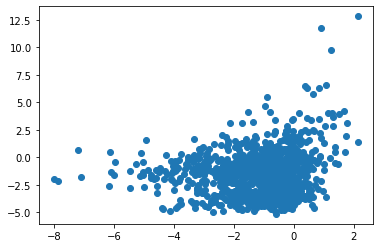

In [4]:
# thres = np.quantile(samples_origin, 0.99,axis=0)

# cond = (samples_origin[:,0] > thres[0] ) | (samples_origin[:,1] > thres[1] ) 
# samples = samples_origin[cond,:]

# thres = thres.reshape(1,-1)
# samples = samples - thres

samples = samples_origin
plt.scatter(samples[:,0],samples[:,1] )


In [5]:
seed = 1234
rng = np.random.default_rng(seed)  # set seed for reproducibility (change/remove if you want)
idx = rng.permutation(len(samples))

split = int(0.8 * len(samples))
train_idx, val_idx = idx[:split], idx[split:]

train_samples = samples[train_idx]
val_samples   = samples[val_idx]

In [74]:
train_samples

array([[-8.00601864e+00, -1.93887663e+00, -9.19005299e+00,
        -1.22597873e+00, -2.43581033e+00, -6.58617401e+00,
        -1.85640264e+00, -1.03329477e+01, -2.63159573e-01,
        -2.37807345e+00, -8.48869228e+00, -1.03081942e+00,
        -9.27614880e+00, -1.88276315e+00, -2.39287424e+00,
        -6.93295956e+00, -1.37578154e+00, -8.94047546e+00,
         3.89846563e-01, -2.41999364e+00, -7.75223827e+00,
        -1.67157733e+00, -9.58543015e+00, -4.01017070e-02,
        -2.43530798e+00],
       [-4.88046408e-01, -1.96845174e-01, -2.86128330e+00,
        -8.55382383e-01, -2.08395171e+00, -4.64842916e-01,
        -5.45561671e-01, -2.63038802e+00, -6.13834262e-01,
        -2.24934840e+00, -1.48375034e-01, -1.12061548e+00,
        -2.36458087e+00, -3.60184014e-01, -2.11208248e+00,
        -2.23371387e-01, -3.64415288e-01, -2.64433932e+00,
         9.82350111e-01, -2.23308301e+00, -2.43498087e-01,
         9.61804390e-03, -2.04207349e+00, -6.95010424e-01,
        -2.15994692e+00],
    

In [125]:
# --- Model & flow architecture (S representation) ---

latent_size = dim - 1   # S flow lives on R^{d-1}
embed_dim = 3*latent_size
base_s = nf.distributions.DiagGaussian(latent_size)

num_layers = 4
torch.manual_seed(0)

b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []

for i in range(num_layers):
    mask = b if i % 2 == 0 else (1 - b)
    s_net = nf.nets.MLP([latent_size + embed_dim, 4 * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    t_net = nf.nets.MLP([latent_size + embed_dim, 4 * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    flows.append(ConditionalMaskedAffineFlow(mask, s_net, t_net))
    flows.append(ActNormConditional(latent_size))

flow_model = ConditionalNormalizingFlow(
    d=dim, embed_dim=embed_dim, flows=flows, base=base_s
).to(device)

batch_size = 64
epochs = 100

model = S_mGPD_NF(
    dim=dim,
    flow=flow_model,
    device=device,
    penalty_lambda=1e4,
    fix_margin=False,
    mse_quantile_lambda=100,
    mmd_lambda=0,
    mmd_zeta=-1.0,
    mmd_h_m=6,
    mmd_h_x=1,
    mmd_alpha=1,
    mmd_epsilon=1e-6,
    mmd_update_margins=False,
)

optimizer = torch.optim.Adam(
    [
        {'params': model.flow_model.parameters(), 'lr': 1e-3},
        {'params': model.data_transform.log_sigma, 'lr': 1e-2},
        {'params': model.data_transform.theta, 'lr': 1e-2},
        {'params': [model.log_pi_raw], 'lr': 1e-3},
    ],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

print('Initial Sigma:', model.get_sigma().detach().cpu().numpy())
print('Initial Gamma:', model.get_gamma().detach().cpu().numpy())

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Make tensors
train_data = torch.tensor(np.asarray(train_samples), dtype=torch.float32, device=device)
val_data = torch.tensor(np.asarray(val_samples), dtype=torch.float32, device=device)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, drop_last=False)

# ---- Early stopping config ----
patience = 15
min_delta = 0.0
best_val = float('inf')
best_state = None
bad_epochs = 0

train_loss_history = []
val_loss_history = []
loss_history = []

torch.autograd.set_detect_anomaly(True)

# Initialise margins with scipy GPD fits
print('Fitting Univariate Margins via Scipy...')
init_sigmas = []
init_gammas = []
for i in range(dim):
    data_i = train_samples[train_samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    init_gammas.append(c)
    init_sigmas.append(scale)
init_gammas = np.array(init_gammas)
init_sigmas = np.array(init_sigmas)
print(f'Scipy Estimated Gammas: {init_gammas.round(3)}')
print(f'Scipy Estimated Sigmas: {init_sigmas.round(3)}')

# --- Stats tracking helpers ---
def init_epoch_stats():
    return {
        'nll': 0.0,
        'support_loss': 0.0,
        'support_loss_weighted': 0.0,
        'mse_quantile_loss': 0.0,
        'mse_quantile_loss_weighted': 0.0,
        'mmd_loss': 0.0,
        'mmd_loss_weighted': 0.0,
        'total_loss': 0.0,
        'count': 0,
    }

def update_epoch_stats(stats_dict, comps, bsz):
    for key in [
        'nll', 'support_loss', 'support_loss_weighted',
        'mse_quantile_loss', 'mse_quantile_loss_weighted',
        'mmd_loss', 'mmd_loss_weighted',
        'total_loss',
    ]:
        stats_dict[key] += comps[key].item() * bsz
    stats_dict['count'] += bsz

def finalize_epoch_stats(stats_dict):
    if stats_dict['count'] == 0:
        return stats_dict
    return {k: (v if k == 'count' else v / stats_dict['count']) for k, v in stats_dict.items()}


for epoch in range(epochs):

    prev_ls = model.data_transform.log_sigma.detach().clone()
    prev_th = model.data_transform.theta.detach().clone()

    # ---------------- TRAIN ----------------
    model.train()
    train_stats = init_epoch_stats()

    for x_data in train_loader:
        comps = model(x_data, return_components=True, x_data_quantile=train_data)
        batch_loss = comps['total_loss']

        if torch.isnan(batch_loss) or torch.isinf(batch_loss):
            print(f'[Epoch {epoch}] NaN/Inf detected in TRAIN loss. Stopping.')
            bad_epochs = patience
            break

        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        update_epoch_stats(train_stats, comps, x_data.shape[0])
        loss_history.append(batch_loss.item())

    train_stats = finalize_epoch_stats(train_stats)
    train_epoch_loss = train_stats['total_loss'] if train_stats['count'] > 0 else float('inf')
    train_loss_history.append(train_epoch_loss)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_stats = init_epoch_stats()

    with torch.no_grad():
        for x_val in val_loader:
            comps = model(x_val, return_components=True)
            val_loss = comps['total_loss']

            if torch.isnan(val_loss) or torch.isinf(val_loss):
                print(f'[Epoch {epoch}] NaN/Inf detected in VAL loss. Stopping.')
                bad_epochs = patience
                break

            update_epoch_stats(val_stats, comps, x_val.shape[0])

    val_stats = finalize_epoch_stats(val_stats)
    val_epoch_loss = val_stats['total_loss'] if val_stats['count'] > 0 else float('inf')
    val_loss_history.append(val_epoch_loss)

    scheduler.step()

    # ---------------- LOGGING ----------------
    lr_now = scheduler.get_last_lr()[0]
    print(
        f"Epoch {epoch+1:4d}/{epochs} | "
        f"train={train_stats['total_loss']:.4f} | "
        f"val={val_stats['total_loss']:.4f} | "
        f"lr={lr_now:.3e}"
    )
    print(
        f"  TRAIN | nll={train_stats['nll']:.4f} | "
        f"supp_w={train_stats['support_loss_weighted']:.4f} | "
        f"mse_q_w={train_stats['mse_quantile_loss_weighted']:.4f} | "
        f"mmd_w={train_stats['mmd_loss_weighted']:.4f}"
    )
    print(
        f"  VALID | nll={val_stats['nll']:.4f} | "
        f"supp_w={val_stats['support_loss_weighted']:.4f} | "
        f"mse_q_w={val_stats['mse_quantile_loss_weighted']:.4f} | "
        f"mmd_w={val_stats['mmd_loss_weighted']:.4f}"
    )

    # ---------------- EARLY STOPPING ----------------
    improved = (best_val - val_epoch_loss) > min_delta

    if improved:
        best_val = val_epoch_loss
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f'Early stopping at epoch {epoch + 1} (no val improvement for {patience} epochs).')
        break

if best_state is not None:
    model.load_state_dict(best_state)

print('Final Gamma:', model.data_transform.get_gamma())
print('Final Sigma:', model.data_transform.get_sigma())


Initial Sigma: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]
Initial Gamma: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
Fitting Univariate Margins via Scipy...
Scipy Estimated Gammas: [-0.043  0.205  0.007  0.054  0.37   0.194  0.152  0.027  0.078  0.394
  0.051  0.247  0.02   0.044  0.357 -0.007  0.196 -0.028  0.04   0.29
 -0.081  0.187  0.004  0.035  0.386]
Scipy Estimated Sigmas: [0.493 1.133 1.001 1.553 0.7   0.328 1.188 0.979 1.336 0.66  0.42  1.044
 0.993 1.445 0.731 0.462 1.11  1.118 1.468 0.75  0.529 1.103 1.036 1.575
 0.679]
Epoch    1/100 | train=87.6714 | val=101.1343 | lr=9.998e-04
  TRAIN | nll=51.4326 | supp_w=0.0000 | mse_q_w=36.2388 | mmd_w=0.0000
  VALID | nll=48.9343 | supp_w=0.0000 | mse_q_w=52.2000 | mmd_w=0.0000
Epoch    2/100 | train=58.1692 | val=74.5705 | lr=9.990e-04
  TRAIN | nll=44.8973 | supp_w=0.0000 | mse_q_w=13.2719 | mmd_w=0.0000
  VALID | nll=43.2041 | supp_w=0.0000 | mse_q_w=31.3665 | mm

In [124]:
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.057840105
0.08263928
0.07319999999999993


In [ ]:
# embed_dim = 72
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.05443189
0.07336445
0.06713333333333328


In [ ]:
# embed_dim = 60
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.051926315
0.08424439
0.06739999999999995


In [ ]:
# embed_dim = 48
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.04053934
0.07356919
0.07339999999999994


In [ ]:
# embed_dim = 36
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.04855704
0.08109238
0.06973333333333327


In [ ]:
# embed_dim = 24
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.05882918
0.08431113
0.08753333333333325


In [112]:
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.043655712
0.078072906
0.08013333333333326


In [ ]:
# dim = 25, mse_quantile_lambda=100, mmd_lambda=10,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.05395162
0.078457825
0.0820666666666666


In [ ]:
# dim = 25, mse_quantile_lambda=100, mmd_lambda=0,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.055480264
0.08243802
0.08686666666666658


In [ ]:
# dim = 25, mse_quantile_lambda=200, mmd_lambda=0,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.047119685
0.080849774
0.09913333333333324


In [ ]:
# dim = 25, mse_quantile_lambda=100, mmd_lambda=0,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.03853853
0.11010484
0.10019999999999991


In [ ]:
# dim = 25, mse_quantile_lambda=10, mmd_lambda=0,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.05998656
0.20175269
0.09886666666666659


In [ ]:
# dim = 25, mse_quantile_lambda=0, mmd_lambda=0,
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

0.078342915
0.24472275
0.09339999999999991


In [ ]:
z

In [ ]:
# dim =5
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim =10
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 20
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 50
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mse_quantile_lambda=1
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mse_quantile_lambda=10
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=10
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=100
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=200
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=50
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=100, mse_quantile_lambda=10
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

In [ ]:
# dim = 25 mmd_lambda=50, mse_quantile_lambda=10
gamma_hat = model.data_transform.get_gamma().cpu().detach()
print(cf.rmse_gamma(gamma_hat, gamma))

sigma_hat = model.data_transform.get_sigma().cpu().detach()
print(cf.rmse_gamma(sigma_hat, sigma))

chi_true = cf.pairwise_chi_from_data(samples_origin)
model.eval()
samples_obs, samples_std, samples_s = model.sample(1000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu)
print(cf.tde_chi(chi_hat, chi_true))

#### Calculate the estimated $\chi(q)$ by Monte Carlo and compare it with the theoretical $\chi$

In [ ]:
n_experiments = 100
n_model_sample = 1000

seed = 1234
Gumble = pv.Bicop(pv.BicopFamily.gumbel, parameters=np.array([[1.3]]))
cop = Gumble
# print(cop)


probs = np.linspace(0.80, 0.996, 100)

Cuu = cop.cdf(np.stack([probs,probs],axis=1))
chi_theorical = (1 - 2*probs + Cuu)/(1-probs)

probs = np.linspace(0.80, 0.996, 100)
# Compute lambda_u for each quantile

# Step 2: Generate samples and compute their KDEs
sample_chi = []

for _ in range(n_experiments):  # Step 3: Repeat 200 times
    model.load_state_dict(torch.load(dir_out + f'Scenairo_2_model_2D_1200_{_}.pt', weights_only=True))
    model.eval()
    samples_obs, samples_std, samples_s = model.sample(n_model_sample)
    sampled_data = samples_obs.cpu().data.numpy()
    sample_chi.append( [cf.empirical_upper_tail_dependence(sampled_data, p) for p in probs])


# Step 3: Calculate the 95% credible interval for the KDE of the samples
sample_chi = np.array(sample_chi)
lower_bound = np.percentile(sample_chi, 2.5, axis=0)
upper_bound = np.percentile(sample_chi, 97.5, axis=0)
mean = np.mean(sample_chi, axis=0)


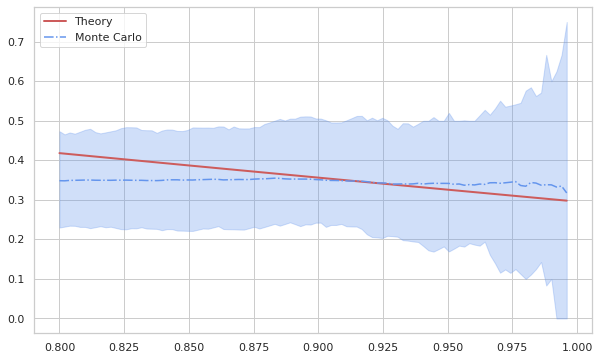

In [ ]:
# Step 4: Plot the KDE of the data and the credible intervals with Seaborn
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the KDE of the data
sns.lineplot(x=probs, y=chi_theorical, label='Theory', color='indianred', linewidth=2)
# plt.hlines(y=chi_theorical, xmin=0.99, xmax=1, color='darkorange', linewidth=3)
# Plot the credible intervals
sns.lineplot(x=probs, y=mean, linestyle='dashdot', color='cornflowerblue', label='Monte Carlo', linewidth=1.5)
# sns.lineplot(x=probs, y=lower_bound, linestyle='--', color='cornflowerblue', label='95% BootStrap CI', linewidth=1.5)
# sns.lineplot(x=probs, y=upper_bound, linestyle='--', color='cornflowerblue', linewidth=1.5)
ax.fill_between(probs, lower_bound, upper_bound, color='cornflowerblue', alpha=0.3, label='95% Credible Interval')

#### Compute the $\mathbb{P}(Y_1 < q_{1,\alpha}, Y_2>q_{2,0.99})$ and compare the theoretical value with the estimated value 

In [ ]:
n_experiments = 100
n_model_sample = 100000
n_bootstrap = 100

u1 = np.arange(0.5,1,0.1)
u2 = np.array([0.99]*len(u1))
prob_non_exceed = cop.cdf(np.stack([u1,u2],axis=1))

prob_partial_exceed = {}
prob = np.log(u1 - prob_non_exceed)
for i in range(len(u1)):
    prob_partial_exceed[f'P(X1<q{u1[i]:.2f}, X2>q{u2[i]:.3f})'] = prob[i]


x1 = norm.ppf(u1, loc=1, scale=3)
# x2 = expon.ppf(u2,  scale =5 )
x2 = norm.ppf(u2, loc=2, scale=5)

prob_exceed_dict =   dict([(f'P(X1<q{u1[i]:.2f}, X2>q{u2[i]:.3f})', []) for i in range(len(x1))])
for _ in range(n_experiments): 
    model.load_state_dict(torch.load(dir_out + f'Scenairo_2_model_2D_1200_{_}.pt', weights_only=True))
    model.eval()
    with torch.no_grad():
        samples_obs, samples_std, samples_s = model.sample(n_model_sample)
    

    with open(dir_out + f'data_2D_10k_{i}.npy', 'rb') as f:
        samples_origin = np.load(f)
        thres = np.load(f)
    samples_data = samples_obs.cpu().data.numpy() + thres
    prob_exceed = np.mean((samples_origin[:,0]>thres.flatten()[0]) | (samples_origin[:,1]>thres.flatten()[1] ) )
    for i in range(len(x1)):
        val = np.log(cf.empirical_survival(samples_data, [x1[i],x2[0]], "<>"))+ np.log(prob_exceed)
        prob_exceed_dict[f'P(X1<q{u1[i]:.2f}, X2>q{u2[i]:.3f})'].append(val)

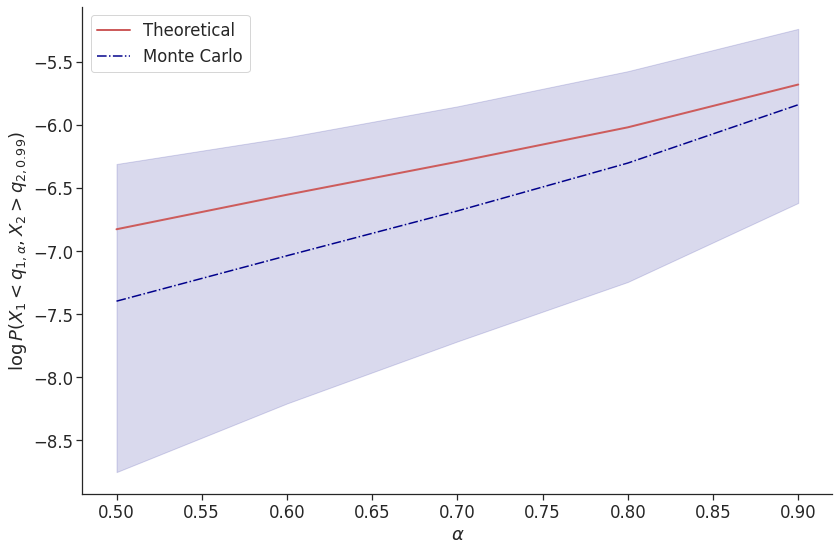

In [ ]:
df = pd.DataFrame(prob_exceed_dict)
prob_partial_exceed_list = [value for key, value in prob_partial_exceed.items() ]

mean = np.mean(df,axis=0)
lower_bound = np.quantile(df, 0.025, axis=0)
upper_bound = np.quantile(df, 0.975, axis=0)

sns.set(style="ticks",font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=u1, y=prob_partial_exceed_list, label='Theoretical', color='indianred', linewidth=2)

sns.lineplot(x=u1, y=mean, linestyle='dashdot', color='darkblue', label='Monte Carlo', linewidth=1.5)

ax.fill_between(u1, lower_bound, upper_bound, color='darkblue', alpha=0.15, label='95% Credible Interval')
plt.ylabel(r'$\log P(X_1<q_{1,\alpha}, X_2>q_{2,0.99})$')
plt.xlabel(r'$\alpha$')
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_2_threshold_exceed_prob.pdf',bbox_inches='tight')

#### Visualize the contour plot of the theoretical density

/home/pgrad2/2448355h/.local/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


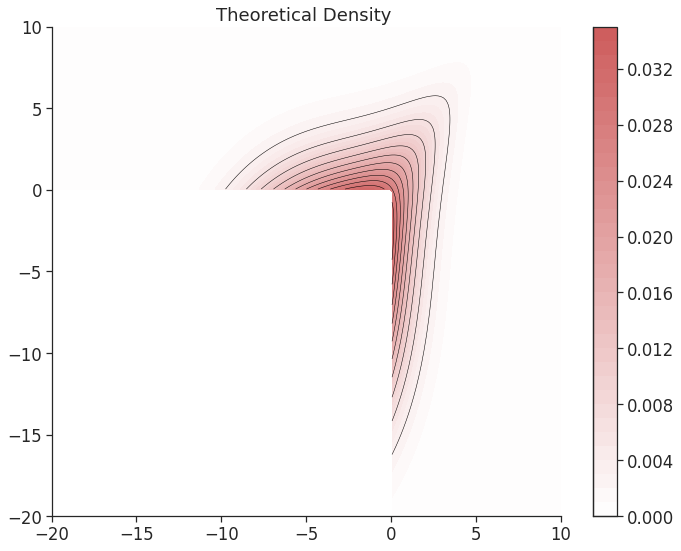

In [ ]:
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-20, 10, grid_size), torch.linspace(-20, 10, grid_size))
thres_x = norm.ppf(0.95, loc=1, scale=3)
thres_y = norm.ppf(0.95, loc=2, scale=5)
thres = (thres_x, thres_y)

xx_np = xx.numpy() + thres_x
yy_np = yy.numpy() + thres_y

# Define the Gumbel copula with parameter 1.3.
Gumble = pv.Bicop(pv.BicopFamily.gumbel, parameters=np.array([[1.3]]))
cop = Gumble

# Compute marginal CDFs for the two normals:
# Margin 1: Normal(loc=1, scale=3)
# Margin 2: Normal(loc=2, scale=5)
u1 = norm.cdf(xx_np, loc=1, scale=3)
u2 = norm.cdf(yy_np, loc=2, scale=5)
u = np.column_stack([u1.ravel(), u2.ravel()])

# Compute the copula density over the grid.
copula_density = cop.pdf(u).reshape(xx_np.shape)

# Compute the marginal PDFs.
f1 = norm.pdf(xx_np, loc=1, scale=3)
f2 = norm.pdf(yy_np, loc=2, scale=5)

prob_thres_exceedance = 1- np.mean(cop.cdf(np.array([[0.95,0.95],[0.95,0.95]])))


# The joint density is given by: density = copula_density * f1 * f2.
density = copula_density * f1 * f2/prob_thres_exceedance



# (Optional: if you want to force density to 0 where both x and y are negative.)
density[(xx_np < thres_x) & (yy_np < thres_y)] = 0

# ---- Define Thresholds and Masking ----
# Define thresholds for each margin.

# Create a mask: only keep points where at least one margin exceeds its threshold.
mask = (xx_np >= thres_x) | (yy_np >= thres_y)
density_masked = np.where(mask, density, np.nan)  # or use 0 instead of np.nan if preferred

# Translate the grid so that the thresholds align at zero.
xx_trans = xx_np - thres_x
yy_trans = yy_np - thres_y

# ---- Plotting ----
# Create a custom colormap: white corresponds to density 0 and blue to maximum density.
cmap = LinearSegmentedColormap.from_list('custom_blue', ['white', 'indianred'], N=256)

sns.set(style="ticks",font_scale=1.5)
plt.figure(figsize=(10, 8))
# Create a filled contour plot with 50 levels.
num_levels = 50
levels = np.unique(np.linspace( 1e-5, 0.035, num_levels).round(3))
contour_filled = plt.contourf(xx_trans, yy_trans, density_masked, levels=levels, cmap=cmap, )
# Optionally, overlay contour lines for enhanced visualization.
plt.contour(xx_trans, yy_trans, density_masked, levels=10, colors='black', linewidths=0.5)
plt.title('Theoretical Density ')
plt.colorbar(contour_filled)
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_2_theoretical_density.pdf',bbox_inches='tight')
plt.show()

#### Visualize the contour plot of the estimated density

In [ ]:
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-20, 10, grid_size), torch.linspace(-20, 10, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

log_prob = torch.zeros((n_experiments,grid_size,grid_size))
with torch.no_grad():
    for _ in range(n_experiments):
        model.load_state_dict(torch.load(dir_out + f'Scenairo_2_model_2D_1200_{_}.pt', weights_only=True))
        log_prob[_] = model.log_prob(zz).to('cpu').view(*xx.shape)
log_prob = torch.mean(log_prob, axis=0)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = np.nan
prob[(xx < 0) & (yy < 0)] = np.nan


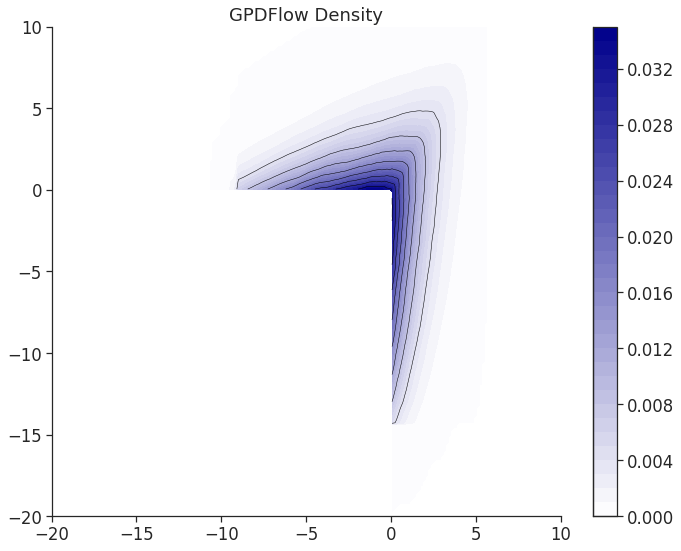

In [ ]:

cmap = LinearSegmentedColormap.from_list('custom_blue', ['white', 'darkblue'], N=256)
density_threshold = 1e-6
density_masked_cleaned = np.where(prob < density_threshold, np.nan, prob)
sns.set(style="ticks",font_scale=1.5)
plt.figure(figsize=(10, 8))
contour_filled = plt.contourf(xx, yy, density_masked_cleaned, levels=levels, cmap=cmap)
# Optionally, overlay contour lines for enhanced visualization.
plt.contour(xx, yy, density_masked_cleaned, levels=10, colors='black', linewidths=0.5)
plt.title('GPDFlow Density')
plt.colorbar(contour_filled)
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_2_GPDFlow_density.pdf',bbox_inches='tight')
plt.show()